# Stochastic Agent-Based Modeling of Palatal Shelf Growth Dynamics: The Role of Periderm Proliferation

This notebook implements a stochastic agent-based model to investigate the biomechanical coordination between the epithelial surface (periderm) and the underlying mesenchyme during palatal shelf outgrowth (E12.5–E14.5). The simulation tests the hypothesis that active periderm self-renewal is essential for accommodating mesenchymal expansion. It models two distinct biological conditions:

1 Wild Type or palate growth with periderm proliferation (WT): Periderm cells undergo both differentiation from the basal layer and autonomous self-renewal, allowing for coordinated tissue expansion.

2 Knockout or palate growth without periderm proliferation (KO): Consistent with Arid3a-cKO phenotypes, periderm cells lose self-renewal capacity, leading to restricted boundary expansion despite normal mesenchymal proliferation.

The model tracks the temporal evolution of mesenchymal cell density and nearest neighbor distance (NND) over a 48-hour period, running N=10 independent stochastic realizations to generate statistically robust time-course data.

## 1 Barplot for mesenchyme cell density and NND

Starting FINAL BIOLOGICAL Statistical Run (n=10)...
  Run 1/10 Completed.
  Run 2/10 Completed.
  Run 3/10 Completed.
  Run 4/10 Completed.
  Run 5/10 Completed.
  Run 6/10 Completed.
  Run 7/10 Completed.
  Run 8/10 Completed.
  Run 9/10 Completed.
  Run 10/10 Completed.
最终带散点统计图已保存: Simulation_Statistics_Scatter.pdf


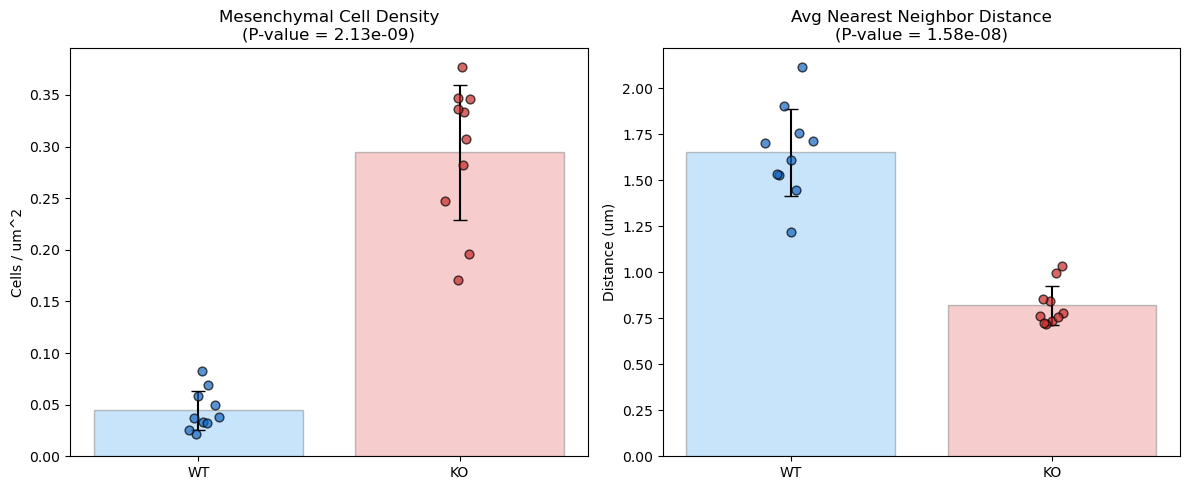


Final Statistics (Biological Model):
WT Mean Density: 0.0444 +/- 0.0188
KO Mean Density: 0.2943 +/- 0.0658


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance, ConvexHull
from scipy.stats import ttest_ind

# ==========================================
# 1. 核心参数 
# ==========================================
INITIAL_RADIUS = 35.0   
PERI_CELL_LEN = 5.0     
MESENCHYME_SIZE = 4.0
TOTAL_TIME = 48
DT = 1.0

# 边界参数
# 统计不需要 VISUAL_SIZE，只需要物理参数
BASAL_SCALE = 0.94       
MESENCHYME_LIMIT = 0.90  

# 细胞动力学参数 (核心机制)
MESENCHYME_PROLIF_RATE = 0.04   # 间充质指数增殖
BASAL_TO_PERIDERM_RATE = 0.015  # 分化速率
PERIDERM_PROLIF_RATE_WT = 0.020 # WT 周皮自增殖
PERIDERM_PROLIF_RATE_KO = 0.0   # KO 周皮无自增殖

class Cell:
    def __init__(self, cell_type, x, y):
        self.type = cell_type
        self.x, self.y = x, y

# ==========================================
# 2. 模拟函数 (生物学驱动版 - 仅返回最终状态)
# ==========================================
def run_simulation_final_stats(is_ko=False, seed=None):
    if seed is not None:
        np.random.seed(seed)
        
    cells = []
    
    # 初始化
    initial_perimeter = np.pi * INITIAL_RADIUS
    num_init_cells = int(initial_perimeter / PERI_CELL_LEN)
    current_num_periderm = num_init_cells
    
    # 间充质初始化 (数量与 Video 保持一致: 200)
    for _ in range(200):
        max_r = INITIAL_RADIUS * MESENCHYME_LIMIT
        r = np.sqrt(np.random.uniform(0, 1)) * (max_r - 1)
        theta = np.random.uniform(0, np.pi)
        cells.append(Cell('Mesenchyme', r * np.cos(theta), r * np.sin(theta)))

    prev_radius = INITIAL_RADIUS
    
    # 循环 (TOTAL_TIME)
    for t in range(int(TOTAL_TIME/DT)):
        
        # --- A. 周皮生长逻辑 (生物学机制) ---
        # 1. 分化来源
        estimated_basal_count = current_num_periderm 
        new_from_basal = np.random.binomial(estimated_basal_count, BASAL_TO_PERIDERM_RATE)
        
        # 2. 自增殖来源 (KO 的关键差异点)
        peri_prolif_rate = PERIDERM_PROLIF_RATE_KO if is_ko else PERIDERM_PROLIF_RATE_WT
        new_from_self = np.random.binomial(current_num_periderm, peri_prolif_rate)
        
        # 更新周皮总数
        current_num_periderm += (new_from_basal + new_from_self)
        
        # --- B. 物理反馈 ---
        max_perimeter = current_num_periderm * PERI_CELL_LEN
        current_radius = max_perimeter / np.pi
        
        expansion_ratio = current_radius / prev_radius if prev_radius > 0 else 1.0
        prev_radius = current_radius
        
        # 拉伸现有细胞
        for c in cells:
            if c.type == 'Mesenchyme':
                c.x *= expansion_ratio
                c.y *= expansion_ratio

        # --- C. 间充质动力学 ---
        current_limit_radius = current_radius * MESENCHYME_LIMIT
        
        # 1. 间充质指数增殖 (WT/KO 速率一致)
        mes_cells = [c for c in cells if c.type == 'Mesenchyme']
        num_mes = len(mes_cells)
        num_new_mes = np.random.binomial(num_mes, MESENCHYME_PROLIF_RATE)
        
        new_mes_list = []
        if num_new_mes > 0:
            parents = np.random.choice(mes_cells, num_new_mes)
            for p in parents:
                # 在父细胞附近分裂
                new_mes_list.append(Cell('Mesenchyme', p.x + np.random.normal(0,1), p.y + np.random.normal(0,1)))
        
        cells.extend(new_mes_list)
        
        # 2. 运动与边界限制
        for c in cells:
            if c.type == 'Mesenchyme':
                c.x += np.random.normal(0, 0.4)
                c.y += np.random.uniform(-0.2, 0.4)
                
                dist = np.sqrt(c.x**2 + c.y**2)
                if dist > current_limit_radius:
                    c.x *= (current_limit_radius / dist)
                    c.y *= (current_limit_radius / dist)

    return cells

# ==========================================
# 3. 计算指标函数 (保持不变)
# ==========================================
def calculate_metrics(cells):
    mes_cells = [c for c in cells if c.type == 'Mesenchyme']
    coords = np.array([[c.x, c.y] for c in mes_cells])
    if len(coords) < 3: return 0, 0
    
    try:
        hull = ConvexHull(coords)
        density = len(mes_cells) / hull.volume
    except:
        density = 0
        
    from scipy.spatial import cKDTree
    tree = cKDTree(coords)
    dists, _ = tree.query(coords, k=2) 
    avg_nnd = np.mean(dists[:, 1]) 
    
    return avg_nnd, density

# ==========================================
# 4. 批量运行
# ==========================================
N_SAMPLES = 10 
print(f"Starting FINAL BIOLOGICAL Statistical Run (n={N_SAMPLES})...")

res = {'WT_den': [], 'KO_den': [], 'WT_nnd': [], 'KO_nnd': []}

for i in range(N_SAMPLES):
    seed = 8888 + i 
    
    # WT
    wt_c = run_simulation_final_stats(is_ko=False, seed=seed)
    nnd, den = calculate_metrics(wt_c)
    res['WT_den'].append(den)
    res['WT_nnd'].append(nnd)
    
    # KO
    ko_c = run_simulation_final_stats(is_ko=True, seed=seed)
    nnd, den = calculate_metrics(ko_c)
    res['KO_den'].append(den)
    res['KO_nnd'].append(nnd)
    
    print(f"  Run {i+1}/{N_SAMPLES} Completed.")

# ==========================================
# 5. 绘图与保存 (修改版：带散点)
# ==========================================
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 定义一个辅助函数来画散点 (Scatter with Jitter)
def add_jitter_points(ax, x_pos, data, color, label):
    # 添加随机抖动 (-0.05 到 0.05) 避免点重叠
    x_jitter = np.random.normal(x_pos, 0.04, size=len(data))
    ax.scatter(x_jitter, data, color=color, alpha=0.7, s=40, edgecolor='black', zorder=3, label=label)

# --- 1. 密度图 ---
mean_wt_den = np.mean(res['WT_den'])
mean_ko_den = np.mean(res['KO_den'])
std_wt_den = np.std(res['WT_den'])
std_ko_den = np.std(res['KO_den'])

# 柱状图 (透明度 alpha 调低，让点更明显)
t_den, p_den = ttest_ind(res['WT_den'], res['KO_den'])
ax[0].bar(['WT', 'KO'], [mean_wt_den, mean_ko_den], 
          yerr=[std_wt_den, std_ko_den], 
          capsize=5, color=['#90caf9', '#ef9a9a'], alpha=0.5, edgecolor='grey', zorder=1)

# 散点图
add_jitter_points(ax[0], 0, res['WT_den'], '#1565c0', 'WT Points') # 深蓝
add_jitter_points(ax[0], 1, res['KO_den'], '#c62828', 'KO Points') # 深红

ax[0].set_title(f'Mesenchymal Cell Density\n(P-value = {p_den:.2e})')
ax[0].set_ylabel('Cells / um^2')

# --- 2. 距离图 ---
mean_wt_nnd = np.mean(res['WT_nnd'])
mean_ko_nnd = np.mean(res['KO_nnd'])
std_wt_nnd = np.std(res['WT_nnd'])
std_ko_nnd = np.std(res['KO_nnd'])

t_nnd, p_nnd = ttest_ind(res['WT_nnd'], res['KO_nnd'])
ax[1].bar(['WT', 'KO'], [mean_wt_nnd, mean_ko_nnd], 
          yerr=[std_wt_nnd, std_ko_nnd], 
          capsize=5, color=['#90caf9', '#ef9a9a'], alpha=0.5, edgecolor='grey', zorder=1)

# 散点图
add_jitter_points(ax[1], 0, res['WT_nnd'], '#1565c0', 'WT Points')
add_jitter_points(ax[1], 1, res['KO_nnd'], '#c62828', 'KO Points')

ax[1].set_title(f'Avg Nearest Neighbor Distance\n(P-value = {p_nnd:.2e})')
ax[1].set_ylabel('Distance (um)')

plt.tight_layout()
plt.savefig('Simulation_Statistics_Scatter.pdf', format='pdf', dpi=300, bbox_inches='tight')
print("最终带散点统计图已保存: Simulation_Statistics_Scatter.pdf")
plt.show()

# 输出最终数值
print(f"\nFinal Statistics (Biological Model):")
print(f"WT Mean Density: {np.mean(res['WT_den']):.4f} +/- {np.std(res['WT_den']):.4f}")
print(f"KO Mean Density: {np.mean(res['KO_den']):.4f} +/- {np.std(res['KO_den']):.4f}")

## 2 Time course plot for mesenchyme cell density and NND

Starting Time-Course Statistical Run (n=10)...
  Run 1/10 Completed.
  Run 2/10 Completed.
  Run 3/10 Completed.
  Run 4/10 Completed.
  Run 5/10 Completed.
  Run 6/10 Completed.
  Run 7/10 Completed.
  Run 8/10 Completed.
  Run 9/10 Completed.
  Run 10/10 Completed.
调整比例后的统计图已保存: Simulation_TimeCourse_Statistics_Ratio_Adjusted.pdf


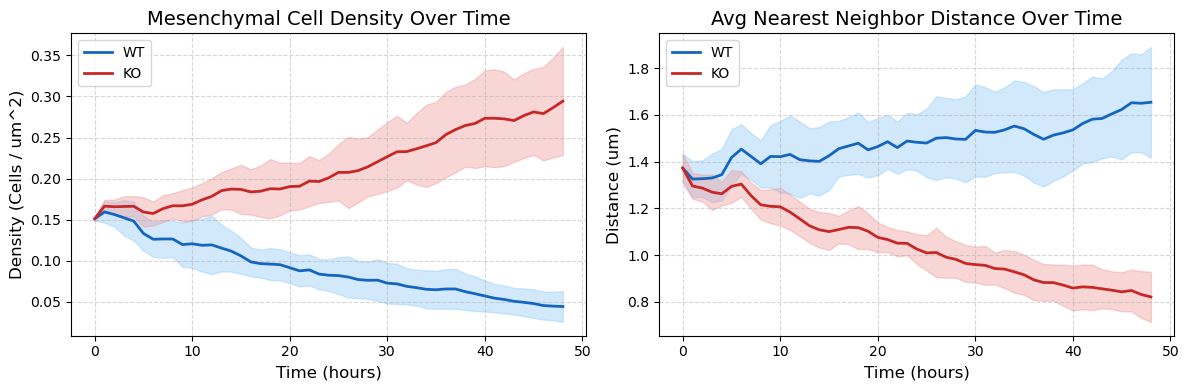

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance, ConvexHull, cKDTree

# ==========================================
# 1. 核心参数 
# ==========================================
INITIAL_RADIUS = 35.0   
PERI_CELL_LEN = 5.0     
MESENCHYME_SIZE = 4.0
TOTAL_TIME = 48
DT = 1.0

# 边界参数
BASAL_SCALE = 0.94        
MESENCHYME_LIMIT = 0.90   

# 细胞动力学参数
MESENCHYME_PROLIF_RATE = 0.04   
BASAL_TO_PERIDERM_RATE = 0.015  
PERIDERM_PROLIF_RATE_WT = 0.020 
PERIDERM_PROLIF_RATE_KO = 0.0   

class Cell:
    def __init__(self, cell_type, x, y):
        self.type = cell_type
        self.x, self.y = x, y

# ==========================================
# 2. 计算指标函数
# ==========================================
def calculate_metrics(cells):
    mes_cells = [c for c in cells if c.type == 'Mesenchyme']
    coords = np.array([[c.x, c.y] for c in mes_cells])
    if len(coords) < 3: return 0, 0
    try:
        hull = ConvexHull(coords)
        density = len(mes_cells) / hull.volume
    except:
        density = 0
    tree = cKDTree(coords)
    dists, _ = tree.query(coords, k=2) 
    avg_nnd = np.mean(dists[:, 1]) 
    return avg_nnd, density

# ==========================================
# 3. 模拟函数 (时间过程版)
# ==========================================
def run_simulation_time_course(is_ko=False, seed=None):
    if seed is not None:
        np.random.seed(seed)
    cells = []
    
    # 初始化
    initial_perimeter = np.pi * INITIAL_RADIUS
    num_init_cells = int(initial_perimeter / PERI_CELL_LEN)
    current_num_periderm = num_init_cells
    
    current_radius = INITIAL_RADIUS
    prev_radius = INITIAL_RADIUS

    for _ in range(200):
        max_r = INITIAL_RADIUS * MESENCHYME_LIMIT
        r = np.sqrt(np.random.uniform(0, 1)) * (max_r - 1)
        theta = np.random.uniform(0, np.pi)
        cells.append(Cell('Mesenchyme', r * np.cos(theta), r * np.sin(theta)))

    num_steps = int(TOTAL_TIME / DT)
    time_points = num_steps + 1
    density_history = np.zeros(time_points)
    nnd_history = np.zeros(time_points)
    
    nnd, den = calculate_metrics(cells)
    density_history[0] = den
    nnd_history[0] = nnd
    
    for t in range(num_steps):
        estimated_basal_count = current_num_periderm 
        new_from_basal = np.random.binomial(estimated_basal_count, BASAL_TO_PERIDERM_RATE)
        peri_prolif_rate = PERIDERM_PROLIF_RATE_KO if is_ko else PERIDERM_PROLIF_RATE_WT
        new_from_self = np.random.binomial(current_num_periderm, peri_prolif_rate)
        current_num_periderm += (new_from_basal + new_from_self)
        
        max_perimeter = current_num_periderm * PERI_CELL_LEN
        current_radius = max_perimeter / np.pi
        expansion_ratio = current_radius / prev_radius if prev_radius > 0 else 1.0
        prev_radius = current_radius
        
        for c in cells:
            if c.type == 'Mesenchyme':
                c.x *= expansion_ratio
                c.y *= expansion_ratio

        current_limit_radius = current_radius * MESENCHYME_LIMIT
        mes_cells = [c for c in cells if c.type == 'Mesenchyme']
        num_mes = len(mes_cells)
        num_new_mes = np.random.binomial(num_mes, MESENCHYME_PROLIF_RATE)
        new_mes_list = []
        if num_new_mes > 0:
            parents = np.random.choice(mes_cells, num_new_mes)
            for p in parents:
                new_mes_list.append(Cell('Mesenchyme', p.x + np.random.normal(0,1), p.y + np.random.normal(0,1)))
        cells.extend(new_mes_list)
        
        for c in cells:
            if c.type == 'Mesenchyme':
                c.x += np.random.normal(0, 0.4)
                c.y += np.random.uniform(-0.2, 0.4)
                dist = np.sqrt(c.x**2 + c.y**2)
                if dist > current_limit_radius:
                    c.x *= (current_limit_radius / dist)
                    c.y *= (current_limit_radius / dist)
        
        nnd, den = calculate_metrics(cells)
        density_history[t+1] = den
        nnd_history[t+1] = nnd

    return density_history, nnd_history

# ==========================================
# 4. 批量运行
# ==========================================
N_SAMPLES = 10 
print(f"Starting Time-Course Statistical Run (n={N_SAMPLES})...")

time_points_count = int(TOTAL_TIME / DT) + 1
wt_den_all = np.zeros((N_SAMPLES, time_points_count))
wt_nnd_all = np.zeros((N_SAMPLES, time_points_count))
ko_den_all = np.zeros((N_SAMPLES, time_points_count))
ko_nnd_all = np.zeros((N_SAMPLES, time_points_count))

for i in range(N_SAMPLES):
    seed = 8888 + i 
    wt_den, wt_nnd = run_simulation_time_course(is_ko=False, seed=seed)
    wt_den_all[i, :] = wt_den
    wt_nnd_all[i, :] = wt_nnd
    ko_den, ko_nnd = run_simulation_time_course(is_ko=True, seed=seed)
    ko_den_all[i, :] = ko_den
    ko_nnd_all[i, :] = ko_nnd
    print(f"  Run {i+1}/{N_SAMPLES} Completed.")

# ==========================================
# 5. 绘图 (调整高宽比)
# ==========================================
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

wt_den_mean = np.mean(wt_den_all, axis=0)
wt_den_std = np.std(wt_den_all, axis=0)
ko_den_mean = np.mean(ko_den_all, axis=0)
ko_den_std = np.std(ko_den_all, axis=0)

wt_nnd_mean = np.mean(wt_nnd_all, axis=0)
wt_nnd_std = np.std(wt_nnd_all, axis=0)
ko_nnd_mean = np.mean(ko_nnd_all, axis=0)
ko_nnd_std = np.std(ko_nnd_all, axis=0)

time_axis = np.arange(0, TOTAL_TIME + DT, DT)

# [关键修改] figsize=(12, 4)
# 两个子图并排。每个图宽约 6，高 4。
# 扣除边距后，绘图区高宽比约为 2.5 : 4
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# --- 1. 密度曲线 ---
ax[0].plot(time_axis, wt_den_mean, color='#1565c0', label='WT', linewidth=2)
ax[0].fill_between(time_axis, wt_den_mean - wt_den_std, wt_den_mean + wt_den_std, color='#90caf9', alpha=0.4)
ax[0].plot(time_axis, ko_den_mean, color='#c62828', label='KO', linewidth=2)
ax[0].fill_between(time_axis, ko_den_mean - ko_den_std, ko_den_mean + ko_den_std, color='#ef9a9a', alpha=0.4)

ax[0].set_title('Mesenchymal Cell Density Over Time', fontsize=14)
ax[0].set_xlabel('Time (hours)', fontsize=12)
ax[0].set_ylabel('Density (Cells / um^2)', fontsize=12)
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.5)

# --- 2. 距离曲线 ---
ax[1].plot(time_axis, wt_nnd_mean, color='#1565c0', label='WT', linewidth=2)
ax[1].fill_between(time_axis, wt_nnd_mean - wt_nnd_std, wt_nnd_mean + wt_nnd_std, color='#90caf9', alpha=0.4)
ax[1].plot(time_axis, ko_nnd_mean, color='#c62828', label='KO', linewidth=2)
ax[1].fill_between(time_axis, ko_nnd_mean - ko_nnd_std, ko_nnd_mean + ko_nnd_std, color='#ef9a9a', alpha=0.4)

ax[1].set_title('Avg Nearest Neighbor Distance Over Time', fontsize=14)
ax[1].set_xlabel('Time (hours)', fontsize=12)
ax[1].set_ylabel('Distance (um)', fontsize=12)
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
# 强制保存为 PDF
plt.savefig('Simulation_TimeCourse_Statistics_Ratio_Adjusted.pdf', format='pdf', dpi=300, bbox_inches='tight')
print("调整比例后的统计图已保存: Simulation_TimeCourse_Statistics_Ratio_Adjusted.pdf")
plt.show()

## 3 Vedio for simulation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

plt.rcParams['animation.ffmpeg_path'] = '/Users/liuhuan/opt/miniconda3/envs/palate_sim/bin/ffmpeg'

# ==========================================
# 1. 核心参数
# ==========================================
INITIAL_RADIUS = 35.0   
PERI_CELL_LEN = 5.0     # [修改] 稍微调小物理尺寸，增加细胞数量，配合变小的视觉点
MESENCHYME_SIZE = 4.0
TOTAL_TIME = 48
DT = 1.0
FRAMES = int(TOTAL_TIME / DT)

# 边界参数
BASAL_SCALE = 0.94       
MESENCHYME_LIMIT = 0.90  

# 细胞动力学参数
MESENCHYME_PROLIF_RATE = 0.04
BASAL_TO_PERIDERM_RATE = 0.015  
PERIDERM_PROLIF_RATE_WT = 0.010
PERIDERM_PROLIF_RATE_KO = 0.0

# ==========================================
# [新增] 视觉显示参数 (控制绘图点的大小)
# ==========================================
VISUAL_SIZE_PERI = 10   # 周皮(圆点)大小
VISUAL_SIZE_BASAL = 12  # 基底(方块)大小
VISUAL_SIZE_MES = 15    # 间充质大小

class Cell:
    def __init__(self, cell_type, x, y):
        self.type = cell_type
        self.x, self.y = x, y

# ==========================================
# 2. 模拟函数 (保持不变)
# ==========================================
def run_simulation_visual_final(is_ko=False, seed=None):
    if seed is not None:
        np.random.seed(seed)
        
    cells = []
    history = [] 
    
    initial_perimeter = np.pi * INITIAL_RADIUS
    num_init_cells = int(initial_perimeter / PERI_CELL_LEN)
    current_num_periderm = num_init_cells
    
    # 间充质初始化
    for _ in range(200):
        max_r = INITIAL_RADIUS * MESENCHYME_LIMIT
        r = np.sqrt(np.random.uniform(0, 1)) * (max_r - 1)
        theta = np.random.uniform(0, np.pi)
        cells.append(Cell('Mesenchyme', r * np.cos(theta), r * np.sin(theta)))

    prev_radius = INITIAL_RADIUS
    
    # Frame 0
    current_frame_cells = [Cell(c.type, c.x, c.y) for c in cells]
    for i in range(current_num_periderm):
        angle = np.pi * i / (current_num_periderm - 1)
        current_frame_cells.append(Cell('Periderm', prev_radius*np.cos(angle), prev_radius*np.sin(angle)))
    
    num_basal_visual = current_num_periderm 
    for i in range(num_basal_visual):
        angle = np.pi * i / (num_basal_visual - 1)
        r_basal = prev_radius * BASAL_SCALE
        current_frame_cells.append(Cell('Basal', r_basal*np.cos(angle), r_basal*np.sin(angle)))
        
    history.append(current_frame_cells)

    # 循环
    for t in range(FRAMES):
        estimated_basal_count = current_num_periderm 
        new_from_basal = np.random.binomial(estimated_basal_count, BASAL_TO_PERIDERM_RATE)
        peri_prolif_rate = PERIDERM_PROLIF_RATE_KO if is_ko else PERIDERM_PROLIF_RATE_WT
        new_from_self = np.random.binomial(current_num_periderm, peri_prolif_rate)
        
        current_num_periderm += (new_from_basal + new_from_self)
        
        max_perimeter = current_num_periderm * PERI_CELL_LEN
        current_radius = max_perimeter / np.pi
        expansion_ratio = current_radius / prev_radius if prev_radius > 0 else 1.0
        prev_radius = current_radius
        
        for c in cells:
            if c.type == 'Mesenchyme':
                c.x *= expansion_ratio
                c.y *= expansion_ratio

        current_limit_radius = current_radius * MESENCHYME_LIMIT
        mes_cells = [c for c in cells if c.type == 'Mesenchyme']
        num_mes = len(mes_cells)
        num_new_mes = np.random.binomial(num_mes, MESENCHYME_PROLIF_RATE)
        
        new_mes_list = []
        if num_new_mes > 0:
            parents = np.random.choice(mes_cells, num_new_mes)
            for p in parents:
                new_mes_list.append(Cell('Mesenchyme', p.x + np.random.normal(0,1), p.y + np.random.normal(0,1)))
        
        cells.extend(new_mes_list)
        
        for c in cells:
            if c.type == 'Mesenchyme':
                c.x += np.random.normal(0, 0.4)
                c.y += np.random.uniform(-0.2, 0.4)
                dist = np.sqrt(c.x**2 + c.y**2)
                if dist > current_limit_radius:
                    c.x *= (current_limit_radius / dist)
                    c.y *= (current_limit_radius / dist)
        
        frame_snapshot = [Cell(c.type, c.x, c.y) for c in cells]
        for i in range(current_num_periderm):
            angle = np.pi * i / (current_num_periderm - 1) if current_num_periderm > 1 else 0
            frame_snapshot.append(Cell('Periderm', current_radius*np.cos(angle), current_radius*np.sin(angle)))
        num_basal_visual = current_num_periderm 
        r_basal = current_radius * BASAL_SCALE
        for i in range(num_basal_visual):
            angle = np.pi * i / (num_basal_visual - 1) if num_basal_visual > 1 else 0
            frame_snapshot.append(Cell('Basal', r_basal*np.cos(angle), r_basal*np.sin(angle)))
            
        history.append(frame_snapshot)

    return history

# ==========================================
# 3. 运行模拟
# ==========================================
VIDEO_SEED = 2026
print("Simulating Visual Refined Model...")
wt_history = run_simulation_visual_final(is_ko=False, seed=VIDEO_SEED)
ko_history = run_simulation_visual_final(is_ko=True, seed=VIDEO_SEED)

print(f"Simulation done. Frames: {len(wt_history)}")

# ==========================================
# 4. 制作动画
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

def init_plot(ax, title):
    ax.set_xlim(-300, 300)
    ax.set_ylim(-10, 320)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=14)
    ax.axis('off')
    
    # 1. 间充质 (使用 VISUAL_SIZE_MES)
    scat_m = ax.scatter([], [], s=VISUAL_SIZE_MES, alpha=0.8, edgecolors='none', zorder=1)
    
    # 2. 虚线 (更细一点)
    line_p, = ax.plot([], [], c='black', linewidth=1.0, linestyle='--', zorder=2)
    
    # 3. 周皮 (使用 VISUAL_SIZE_PERI)
    scat_p = ax.scatter([], [], c='black', s=VISUAL_SIZE_PERI, zorder=3, label='Periderm')
    
    # 4. 基底 (使用 VISUAL_SIZE_BASAL)
    # 线宽也稍微改细一点，显得精致
    scat_b = ax.scatter([], [], marker='s', s=VISUAL_SIZE_BASAL, edgecolors='black', linewidth=0.5, zorder=4, label='Basal')
    
    time_text = ax.text(0.05, 0.95, '', transform=ax.transAxes, fontsize=12)
    return scat_m, scat_p, scat_b, line_p, time_text

wt_m, wt_p, wt_b, wt_line, wt_time = init_plot(ax1, "Periderm with proliferation")
ko_m, ko_p, ko_b, ko_line, ko_time = init_plot(ax2, "Periderm no proliferation:")

def update(frame):
    # --- WT ---
    cells = wt_history[frame]
    mx = [c.x for c in cells if c.type == 'Mesenchyme']
    my = [c.y for c in cells if c.type == 'Mesenchyme']
    
    peri = [c for c in cells if c.type == 'Periderm']
    peri.sort(key=lambda c: np.arctan2(c.y, c.x))
    px = [c.x for c in peri]
    py = [c.y for c in peri]
    
    basal = [c for c in cells if c.type == 'Basal']
    bx = [c.x for c in basal]
    by = [c.y for c in basal]
    
    wt_m.set_offsets(np.c_[mx, my])
    wt_m.set_facecolor('#90caf9')
    wt_p.set_offsets(np.c_[px, py])
    wt_line.set_data(px, py)
    wt_b.set_offsets(np.c_[bx, by])
    wt_b.set_facecolor('#4db6ac')
    wt_time.set_text(f'Time: {frame} h')
    
    # --- KO ---
    cells_ko = ko_history[frame]
    mx_ko = [c.x for c in cells_ko if c.type == 'Mesenchyme']
    my_ko = [c.y for c in cells_ko if c.type == 'Mesenchyme']
    
    peri_ko = [c for c in cells_ko if c.type == 'Periderm']
    peri_ko.sort(key=lambda c: np.arctan2(c.y, c.x))
    px_ko = [c.x for c in peri_ko]
    py_ko = [c.y for c in peri_ko]
    
    basal_ko = [c for c in cells_ko if c.type == 'Basal']
    bx_ko = [c.x for c in basal_ko]
    by_ko = [c.y for c in basal_ko]
    
    ko_m.set_offsets(np.c_[mx_ko, my_ko])
    ko_m.set_facecolor('#ef9a9a')
    ko_p.set_offsets(np.c_[px_ko, py_ko])
    ko_line.set_data(px_ko, py_ko)
    ko_b.set_offsets(np.c_[bx_ko, by_ko])
    ko_b.set_facecolor('#ffb74d')
    ko_time.set_text(f'Time: {frame} h')
    
    return wt_m, wt_p, wt_b, wt_line, wt_time, ko_m, ko_p, ko_b, ko_line, ko_time

ani = FuncAnimation(fig, update, frames=len(wt_history), interval=100, blit=True)
ani.save('Palate_Growth_wo_periderm_proliferation.mp4', writer='ffmpeg', fps=10, dpi=200)

print("Video Saved: Palate_Growth_wo_periderm_proliferation.mp4")
plt.close()

## 4 Snapshot for simulation

Generating Final Synchronized Snapshots...
最终快照已保存为: Simulation_Snapshots_48h.pdf


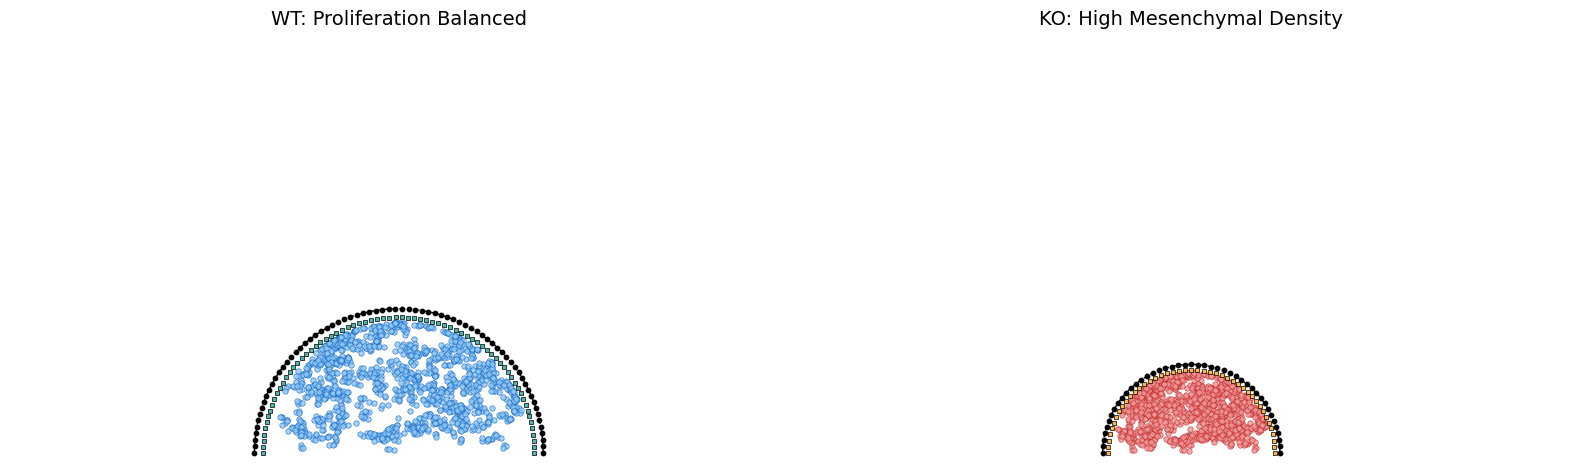

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 核心参数 (完全同步你的 Video 参数)
# ==========================================
INITIAL_RADIUS = 35.0   
PERI_CELL_LEN = 5.0     # [同步] 物理尺寸 5.0
MESENCHYME_SIZE = 4.0
TOTAL_TIME = 48
DT = 1.0

# 边界参数
BASAL_SCALE = 0.94       
MESENCHYME_LIMIT = 0.90  

# 细胞动力学参数
MESENCHYME_PROLIF_RATE = 0.04
BASAL_TO_PERIDERM_RATE = 0.015  
PERIDERM_PROLIF_RATE_WT = 0.010
PERIDERM_PROLIF_RATE_KO = 0.0

# ==========================================
# [同步] 视觉显示参数
# ==========================================
VISUAL_SIZE_PERI = 10   # 周皮(圆点)大小
VISUAL_SIZE_BASAL = 12  # 基底(方块)大小
VISUAL_SIZE_MES = 15    # 间充质大小

class Cell:
    def __init__(self, cell_type, x, y):
        self.type = cell_type
        self.x, self.y = x, y

# ==========================================
# 2. 模拟函数 (Snapshot 版 - 只需返回最终状态)
# ==========================================
def run_simulation_final_snapshot(is_ko=False, seed=None):
    if seed is not None:
        np.random.seed(seed)
        
    cells = []
    
    # 初始化
    initial_perimeter = np.pi * INITIAL_RADIUS
    num_init_cells = int(initial_perimeter / PERI_CELL_LEN)
    current_num_periderm = num_init_cells
    
    # 间充质初始化 (200个)
    for _ in range(200):
        max_r = INITIAL_RADIUS * MESENCHYME_LIMIT
        r = np.sqrt(np.random.uniform(0, 1)) * (max_r - 1)
        theta = np.random.uniform(0, np.pi)
        cells.append(Cell('Mesenchyme', r * np.cos(theta), r * np.sin(theta)))

    prev_radius = INITIAL_RADIUS
    
    # 循环
    for t in range(int(TOTAL_TIME/DT)):
        
        # A. 周皮生长 (分化 + 自增殖)
        estimated_basal_count = current_num_periderm 
        new_from_basal = np.random.binomial(estimated_basal_count, BASAL_TO_PERIDERM_RATE)
        
        peri_prolif_rate = PERIDERM_PROLIF_RATE_KO if is_ko else PERIDERM_PROLIF_RATE_WT
        new_from_self = np.random.binomial(current_num_periderm, peri_prolif_rate)
        
        current_num_periderm += (new_from_basal + new_from_self)
        
        # B. 物理反馈
        max_perimeter = current_num_periderm * PERI_CELL_LEN
        current_radius = max_perimeter / np.pi
        
        expansion_ratio = current_radius / prev_radius if prev_radius > 0 else 1.0
        prev_radius = current_radius
        
        for c in cells:
            if c.type == 'Mesenchyme':
                c.x *= expansion_ratio
                c.y *= expansion_ratio

        # C. 间充质动力学 (指数增殖 + 边界限制)
        current_limit_radius = current_radius * MESENCHYME_LIMIT
        
        mes_cells = [c for c in cells if c.type == 'Mesenchyme']
        num_mes = len(mes_cells)
        num_new_mes = np.random.binomial(num_mes, MESENCHYME_PROLIF_RATE)
        
        new_mes_list = []
        if num_new_mes > 0:
            parents = np.random.choice(mes_cells, num_new_mes)
            for p in parents:
                new_mes_list.append(Cell('Mesenchyme', p.x + np.random.normal(0,1), p.y + np.random.normal(0,1)))
        
        cells.extend(new_mes_list)
        
        for c in cells:
            if c.type == 'Mesenchyme':
                c.x += np.random.normal(0, 0.4)
                c.y += np.random.uniform(-0.2, 0.4)
                dist = np.sqrt(c.x**2 + c.y**2)
                if dist > current_limit_radius:
                    c.x *= (current_limit_radius / dist)
                    c.y *= (current_limit_radius / dist)

    # --- 最终状态组装 ---
    # 这一步是为了生成画图用的列表
    final_snapshot = [c for c in cells] # 只有间充质
    
    # 添加最终周皮
    for i in range(current_num_periderm):
        angle = np.pi * i / (current_num_periderm - 1) if current_num_periderm > 1 else 0
        final_snapshot.append(Cell('Periderm', current_radius*np.cos(angle), current_radius*np.sin(angle)))
        
    # 添加最终基底 (视觉上与周皮 1:1)
    num_basal_visual = current_num_periderm
    r_basal = current_radius * BASAL_SCALE
    for i in range(num_basal_visual):
        angle = np.pi * i / (num_basal_visual - 1) if num_basal_visual > 1 else 0
        final_snapshot.append(Cell('Basal', r_basal*np.cos(angle), r_basal*np.sin(angle)))
        
    return final_snapshot

# ==========================================
# 绘图函数 (视觉优化版 - 匹配 Video)
# ==========================================
def plot_simulation_snapshot_final(ax, cells, title, color_theme='red'):
    mes_cells = [c for c in cells if c.type == 'Mesenchyme']
    peri_cells = [c for c in cells if c.type == 'Periderm']
    basal_cells = [c for c in cells if c.type == 'Basal'] 
    
    mx = [c.x for c in mes_cells]
    my = [c.y for c in mes_cells]
    
    if color_theme == 'red':
        m_color = '#ef9a9a' 
        m_edge = '#c62828'
        basal_color = '#ffb74d' 
    else:
        m_color = '#90caf9' 
        m_edge = '#1565c0'
        basal_color = '#4db6ac' 
        
    # 1. 间充质 (使用 VISUAL_SIZE_MES)
    ax.scatter(mx, my, c=m_color, s=VISUAL_SIZE_MES, alpha=0.8, edgecolors=m_edge, linewidth=0.5, label='Mesenchyme', zorder=1)
    
    # 2. 周皮
    peri_sorted = sorted(peri_cells, key=lambda c: np.arctan2(c.y, c.x))
    px = [c.x for c in peri_sorted]
    py = [c.y for c in peri_sorted]
    
    # 虚线画细一点
    ax.plot(px, py, c='black', linewidth=1.0, linestyle='--', zorder=2) 
    # 使用 VISUAL_SIZE_PERI
    ax.scatter(px, py, c='black', s=VISUAL_SIZE_PERI, marker='o', zorder=3, label='Periderm')
    
    # 3. 基底 (使用 VISUAL_SIZE_BASAL)
    bx = [c.x for c in basal_cells]
    by = [c.y for c in basal_cells]
    ax.scatter(bx, by, c=basal_color, s=VISUAL_SIZE_BASAL, marker='s', edgecolors='black', linewidth=0.5, zorder=4, label='Basal')

    ax.set_title(title, fontsize=14, pad=10)
    ax.set_aspect('equal')
    
    # [关键] 统一宽视野 (-300, 300)
    ax.set_xlim(-300, 300)
    ax.set_ylim(-10, 320)
    ax.axis('off')

# ==========================================
# 运行并保存
# ==========================================
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

PLOT_SEED = 2026
print("Generating Final Synchronized Snapshots...")

wt_snapshot = run_simulation_final_snapshot(is_ko=False, seed=PLOT_SEED)
ko_snapshot = run_simulation_final_snapshot(is_ko=True, seed=PLOT_SEED)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8)) # 画布调大

plot_simulation_snapshot_final(ax1, wt_snapshot, "WT: Proliferation Balanced", color_theme='blue')
plot_simulation_snapshot_final(ax2, ko_snapshot, "KO: High Mesenchymal Density", color_theme='red')

plt.tight_layout()
plt.savefig('Simulation_Snapshots_48h.pdf', format='pdf', dpi=300, bbox_inches='tight')
print("最终快照已保存为: Simulation_Snapshots_48h.pdf")

plt.show()

Generating Final Synchronized Snapshots...
最终快照已保存为: Simulation_Snapshots_12h.pdf


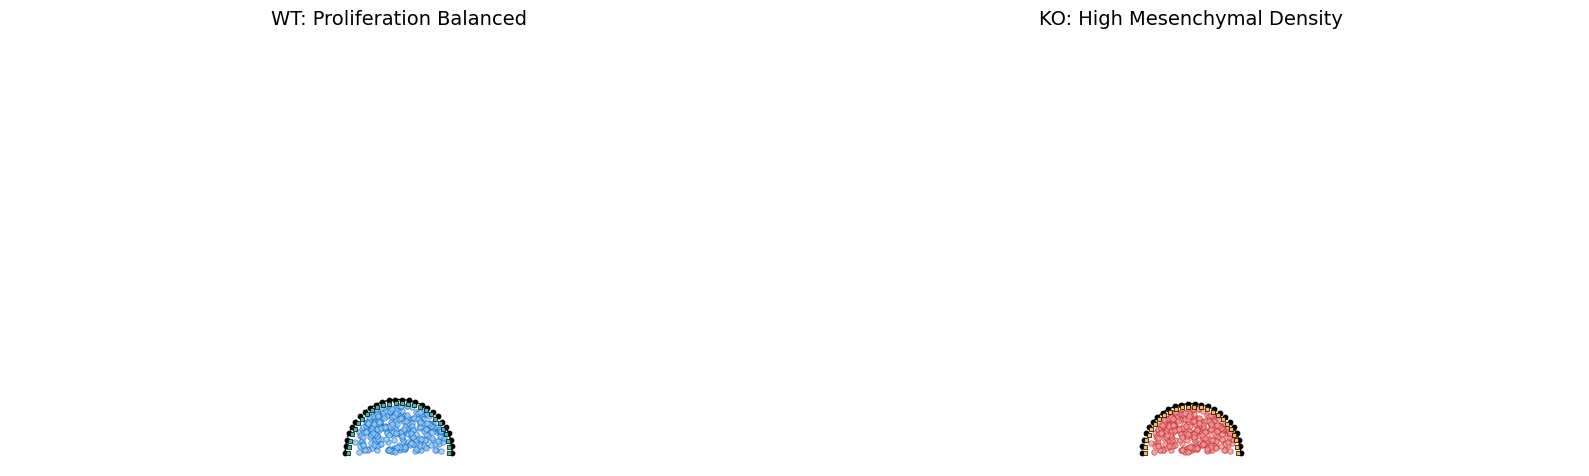

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 核心参数 (完全同步你的 Video 参数)
# ==========================================
INITIAL_RADIUS = 35.0   
PERI_CELL_LEN = 5.0     # [同步] 物理尺寸 5.0
MESENCHYME_SIZE = 4.0
TOTAL_TIME = 12
DT = 1.0

# 边界参数
BASAL_SCALE = 0.94       
MESENCHYME_LIMIT = 0.90  

# 细胞动力学参数
MESENCHYME_PROLIF_RATE = 0.04
BASAL_TO_PERIDERM_RATE = 0.015  
PERIDERM_PROLIF_RATE_WT = 0.010
PERIDERM_PROLIF_RATE_KO = 0.0

# ==========================================
# [同步] 视觉显示参数
# ==========================================
VISUAL_SIZE_PERI = 10   # 周皮(圆点)大小
VISUAL_SIZE_BASAL = 12  # 基底(方块)大小
VISUAL_SIZE_MES = 15    # 间充质大小

class Cell:
    def __init__(self, cell_type, x, y):
        self.type = cell_type
        self.x, self.y = x, y

# ==========================================
# 2. 模拟函数 (Snapshot 版 - 只需返回最终状态)
# ==========================================
def run_simulation_final_snapshot(is_ko=False, seed=None):
    if seed is not None:
        np.random.seed(seed)
        
    cells = []
    
    # 初始化
    initial_perimeter = np.pi * INITIAL_RADIUS
    num_init_cells = int(initial_perimeter / PERI_CELL_LEN)
    current_num_periderm = num_init_cells
    
    # 间充质初始化 (200个)
    for _ in range(200):
        max_r = INITIAL_RADIUS * MESENCHYME_LIMIT
        r = np.sqrt(np.random.uniform(0, 1)) * (max_r - 1)
        theta = np.random.uniform(0, np.pi)
        cells.append(Cell('Mesenchyme', r * np.cos(theta), r * np.sin(theta)))

    prev_radius = INITIAL_RADIUS
    
    # 循环
    for t in range(int(TOTAL_TIME/DT)):
        
        # A. 周皮生长 (分化 + 自增殖)
        estimated_basal_count = current_num_periderm 
        new_from_basal = np.random.binomial(estimated_basal_count, BASAL_TO_PERIDERM_RATE)
        
        peri_prolif_rate = PERIDERM_PROLIF_RATE_KO if is_ko else PERIDERM_PROLIF_RATE_WT
        new_from_self = np.random.binomial(current_num_periderm, peri_prolif_rate)
        
        current_num_periderm += (new_from_basal + new_from_self)
        
        # B. 物理反馈
        max_perimeter = current_num_periderm * PERI_CELL_LEN
        current_radius = max_perimeter / np.pi
        
        expansion_ratio = current_radius / prev_radius if prev_radius > 0 else 1.0
        prev_radius = current_radius
        
        for c in cells:
            if c.type == 'Mesenchyme':
                c.x *= expansion_ratio
                c.y *= expansion_ratio

        # C. 间充质动力学 (指数增殖 + 边界限制)
        current_limit_radius = current_radius * MESENCHYME_LIMIT
        
        mes_cells = [c for c in cells if c.type == 'Mesenchyme']
        num_mes = len(mes_cells)
        num_new_mes = np.random.binomial(num_mes, MESENCHYME_PROLIF_RATE)
        
        new_mes_list = []
        if num_new_mes > 0:
            parents = np.random.choice(mes_cells, num_new_mes)
            for p in parents:
                new_mes_list.append(Cell('Mesenchyme', p.x + np.random.normal(0,1), p.y + np.random.normal(0,1)))
        
        cells.extend(new_mes_list)
        
        for c in cells:
            if c.type == 'Mesenchyme':
                c.x += np.random.normal(0, 0.4)
                c.y += np.random.uniform(-0.2, 0.4)
                dist = np.sqrt(c.x**2 + c.y**2)
                if dist > current_limit_radius:
                    c.x *= (current_limit_radius / dist)
                    c.y *= (current_limit_radius / dist)

    # --- 最终状态组装 ---
    # 这一步是为了生成画图用的列表
    final_snapshot = [c for c in cells] # 只有间充质
    
    # 添加最终周皮
    for i in range(current_num_periderm):
        angle = np.pi * i / (current_num_periderm - 1) if current_num_periderm > 1 else 0
        final_snapshot.append(Cell('Periderm', current_radius*np.cos(angle), current_radius*np.sin(angle)))
        
    # 添加最终基底 (视觉上与周皮 1:1)
    num_basal_visual = current_num_periderm
    r_basal = current_radius * BASAL_SCALE
    for i in range(num_basal_visual):
        angle = np.pi * i / (num_basal_visual - 1) if num_basal_visual > 1 else 0
        final_snapshot.append(Cell('Basal', r_basal*np.cos(angle), r_basal*np.sin(angle)))
        
    return final_snapshot

# ==========================================
# 绘图函数 (视觉优化版 - 匹配 Video)
# ==========================================
def plot_simulation_snapshot_final(ax, cells, title, color_theme='red'):
    mes_cells = [c for c in cells if c.type == 'Mesenchyme']
    peri_cells = [c for c in cells if c.type == 'Periderm']
    basal_cells = [c for c in cells if c.type == 'Basal'] 
    
    mx = [c.x for c in mes_cells]
    my = [c.y for c in mes_cells]
    
    if color_theme == 'red':
        m_color = '#ef9a9a' 
        m_edge = '#c62828'
        basal_color = '#ffb74d' 
    else:
        m_color = '#90caf9' 
        m_edge = '#1565c0'
        basal_color = '#4db6ac' 
        
    # 1. 间充质 (使用 VISUAL_SIZE_MES)
    ax.scatter(mx, my, c=m_color, s=VISUAL_SIZE_MES, alpha=0.8, edgecolors=m_edge, linewidth=0.5, label='Mesenchyme', zorder=1)
    
    # 2. 周皮
    peri_sorted = sorted(peri_cells, key=lambda c: np.arctan2(c.y, c.x))
    px = [c.x for c in peri_sorted]
    py = [c.y for c in peri_sorted]
    
    # 虚线画细一点
    ax.plot(px, py, c='black', linewidth=1.0, linestyle='--', zorder=2) 
    # 使用 VISUAL_SIZE_PERI
    ax.scatter(px, py, c='black', s=VISUAL_SIZE_PERI, marker='o', zorder=3, label='Periderm')
    
    # 3. 基底 (使用 VISUAL_SIZE_BASAL)
    bx = [c.x for c in basal_cells]
    by = [c.y for c in basal_cells]
    ax.scatter(bx, by, c=basal_color, s=VISUAL_SIZE_BASAL, marker='s', edgecolors='black', linewidth=0.5, zorder=4, label='Basal')

    ax.set_title(title, fontsize=14, pad=10)
    ax.set_aspect('equal')
    
    # [关键] 统一宽视野 (-300, 300)
    ax.set_xlim(-300, 300)
    ax.set_ylim(-10, 320)
    ax.axis('off')

# ==========================================
# 运行并保存
# ==========================================
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

PLOT_SEED = 2026
print("Generating Final Synchronized Snapshots...")

wt_snapshot = run_simulation_final_snapshot(is_ko=False, seed=PLOT_SEED)
ko_snapshot = run_simulation_final_snapshot(is_ko=True, seed=PLOT_SEED)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8)) # 画布调大

plot_simulation_snapshot_final(ax1, wt_snapshot, "WT: Proliferation Balanced", color_theme='blue')
plot_simulation_snapshot_final(ax2, ko_snapshot, "KO: High Mesenchymal Density", color_theme='red')

plt.tight_layout()
plt.savefig('Simulation_Snapshots_12h.pdf', format='pdf', dpi=300, bbox_inches='tight')
print("最终快照已保存为: Simulation_Snapshots_12h.pdf")

plt.show()

Generating Final Synchronized Snapshots...
最终快照已保存为: Simulation_Snapshots_24h.pdf


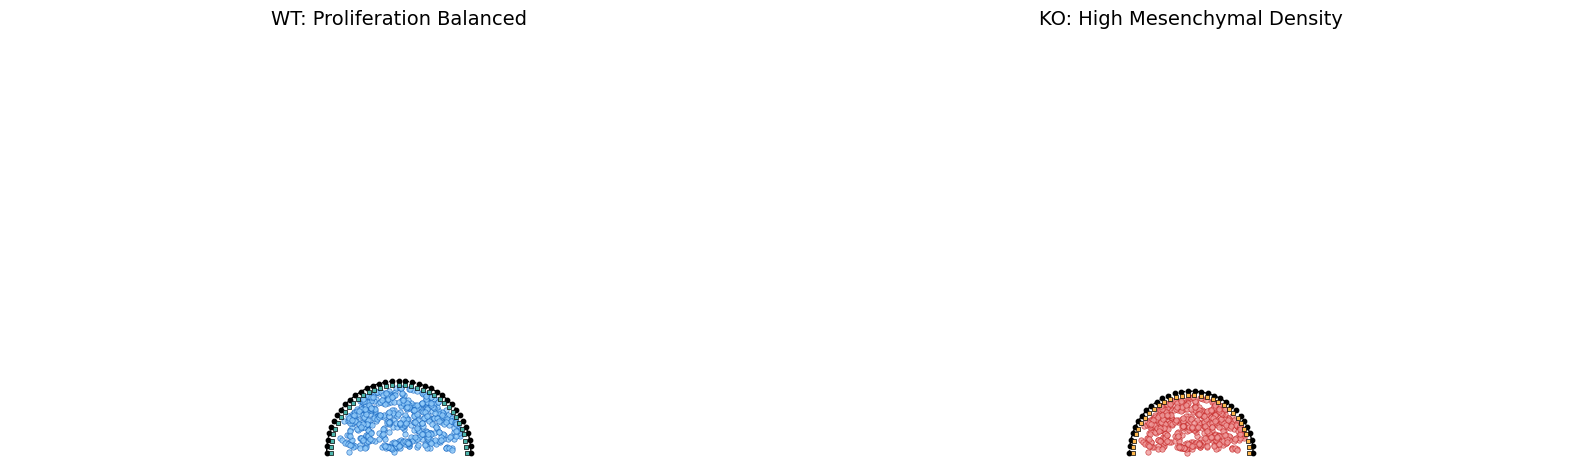

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 核心参数 (完全同步你的 Video 参数)
# ==========================================
INITIAL_RADIUS = 35.0   
PERI_CELL_LEN = 5.0     # [同步] 物理尺寸 5.0
MESENCHYME_SIZE = 4.0
TOTAL_TIME = 24
DT = 1.0

# 边界参数
BASAL_SCALE = 0.94       
MESENCHYME_LIMIT = 0.90  

# 细胞动力学参数
MESENCHYME_PROLIF_RATE = 0.04
BASAL_TO_PERIDERM_RATE = 0.015  
PERIDERM_PROLIF_RATE_WT = 0.010
PERIDERM_PROLIF_RATE_KO = 0.0

# ==========================================
# [同步] 视觉显示参数
# ==========================================
VISUAL_SIZE_PERI = 10   # 周皮(圆点)大小
VISUAL_SIZE_BASAL = 12  # 基底(方块)大小
VISUAL_SIZE_MES = 15    # 间充质大小

class Cell:
    def __init__(self, cell_type, x, y):
        self.type = cell_type
        self.x, self.y = x, y

# ==========================================
# 2. 模拟函数 (Snapshot 版 - 只需返回最终状态)
# ==========================================
def run_simulation_final_snapshot(is_ko=False, seed=None):
    if seed is not None:
        np.random.seed(seed)
        
    cells = []
    
    # 初始化
    initial_perimeter = np.pi * INITIAL_RADIUS
    num_init_cells = int(initial_perimeter / PERI_CELL_LEN)
    current_num_periderm = num_init_cells
    
    # 间充质初始化 (200个)
    for _ in range(200):
        max_r = INITIAL_RADIUS * MESENCHYME_LIMIT
        r = np.sqrt(np.random.uniform(0, 1)) * (max_r - 1)
        theta = np.random.uniform(0, np.pi)
        cells.append(Cell('Mesenchyme', r * np.cos(theta), r * np.sin(theta)))

    prev_radius = INITIAL_RADIUS
    
    # 循环
    for t in range(int(TOTAL_TIME/DT)):
        
        # A. 周皮生长 (分化 + 自增殖)
        estimated_basal_count = current_num_periderm 
        new_from_basal = np.random.binomial(estimated_basal_count, BASAL_TO_PERIDERM_RATE)
        
        peri_prolif_rate = PERIDERM_PROLIF_RATE_KO if is_ko else PERIDERM_PROLIF_RATE_WT
        new_from_self = np.random.binomial(current_num_periderm, peri_prolif_rate)
        
        current_num_periderm += (new_from_basal + new_from_self)
        
        # B. 物理反馈
        max_perimeter = current_num_periderm * PERI_CELL_LEN
        current_radius = max_perimeter / np.pi
        
        expansion_ratio = current_radius / prev_radius if prev_radius > 0 else 1.0
        prev_radius = current_radius
        
        for c in cells:
            if c.type == 'Mesenchyme':
                c.x *= expansion_ratio
                c.y *= expansion_ratio

        # C. 间充质动力学 (指数增殖 + 边界限制)
        current_limit_radius = current_radius * MESENCHYME_LIMIT
        
        mes_cells = [c for c in cells if c.type == 'Mesenchyme']
        num_mes = len(mes_cells)
        num_new_mes = np.random.binomial(num_mes, MESENCHYME_PROLIF_RATE)
        
        new_mes_list = []
        if num_new_mes > 0:
            parents = np.random.choice(mes_cells, num_new_mes)
            for p in parents:
                new_mes_list.append(Cell('Mesenchyme', p.x + np.random.normal(0,1), p.y + np.random.normal(0,1)))
        
        cells.extend(new_mes_list)
        
        for c in cells:
            if c.type == 'Mesenchyme':
                c.x += np.random.normal(0, 0.4)
                c.y += np.random.uniform(-0.2, 0.4)
                dist = np.sqrt(c.x**2 + c.y**2)
                if dist > current_limit_radius:
                    c.x *= (current_limit_radius / dist)
                    c.y *= (current_limit_radius / dist)

    # --- 最终状态组装 ---
    # 这一步是为了生成画图用的列表
    final_snapshot = [c for c in cells] # 只有间充质
    
    # 添加最终周皮
    for i in range(current_num_periderm):
        angle = np.pi * i / (current_num_periderm - 1) if current_num_periderm > 1 else 0
        final_snapshot.append(Cell('Periderm', current_radius*np.cos(angle), current_radius*np.sin(angle)))
        
    # 添加最终基底 (视觉上与周皮 1:1)
    num_basal_visual = current_num_periderm
    r_basal = current_radius * BASAL_SCALE
    for i in range(num_basal_visual):
        angle = np.pi * i / (num_basal_visual - 1) if num_basal_visual > 1 else 0
        final_snapshot.append(Cell('Basal', r_basal*np.cos(angle), r_basal*np.sin(angle)))
        
    return final_snapshot

# ==========================================
# 绘图函数 (视觉优化版 - 匹配 Video)
# ==========================================
def plot_simulation_snapshot_final(ax, cells, title, color_theme='red'):
    mes_cells = [c for c in cells if c.type == 'Mesenchyme']
    peri_cells = [c for c in cells if c.type == 'Periderm']
    basal_cells = [c for c in cells if c.type == 'Basal'] 
    
    mx = [c.x for c in mes_cells]
    my = [c.y for c in mes_cells]
    
    if color_theme == 'red':
        m_color = '#ef9a9a' 
        m_edge = '#c62828'
        basal_color = '#ffb74d' 
    else:
        m_color = '#90caf9' 
        m_edge = '#1565c0'
        basal_color = '#4db6ac' 
        
    # 1. 间充质 (使用 VISUAL_SIZE_MES)
    ax.scatter(mx, my, c=m_color, s=VISUAL_SIZE_MES, alpha=0.8, edgecolors=m_edge, linewidth=0.5, label='Mesenchyme', zorder=1)
    
    # 2. 周皮
    peri_sorted = sorted(peri_cells, key=lambda c: np.arctan2(c.y, c.x))
    px = [c.x for c in peri_sorted]
    py = [c.y for c in peri_sorted]
    
    # 虚线画细一点
    ax.plot(px, py, c='black', linewidth=1.0, linestyle='--', zorder=2) 
    # 使用 VISUAL_SIZE_PERI
    ax.scatter(px, py, c='black', s=VISUAL_SIZE_PERI, marker='o', zorder=3, label='Periderm')
    
    # 3. 基底 (使用 VISUAL_SIZE_BASAL)
    bx = [c.x for c in basal_cells]
    by = [c.y for c in basal_cells]
    ax.scatter(bx, by, c=basal_color, s=VISUAL_SIZE_BASAL, marker='s', edgecolors='black', linewidth=0.5, zorder=4, label='Basal')

    ax.set_title(title, fontsize=14, pad=10)
    ax.set_aspect('equal')
    
    # [关键] 统一宽视野 (-300, 300)
    ax.set_xlim(-300, 300)
    ax.set_ylim(-10, 320)
    ax.axis('off')

# ==========================================
# 运行并保存
# ==========================================
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

PLOT_SEED = 2026
print("Generating Final Synchronized Snapshots...")

wt_snapshot = run_simulation_final_snapshot(is_ko=False, seed=PLOT_SEED)
ko_snapshot = run_simulation_final_snapshot(is_ko=True, seed=PLOT_SEED)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8)) # 画布调大

plot_simulation_snapshot_final(ax1, wt_snapshot, "WT: Proliferation Balanced", color_theme='blue')
plot_simulation_snapshot_final(ax2, ko_snapshot, "KO: High Mesenchymal Density", color_theme='red')

plt.tight_layout()
plt.savefig('Simulation_Snapshots_24h.pdf', format='pdf', dpi=300, bbox_inches='tight')
print("最终快照已保存为: Simulation_Snapshots_24h.pdf")

plt.show()

Generating Final Synchronized Snapshots (0h)...
最终快照 (0h) 已保存为: Simulation_Snapshots_0h.pdf


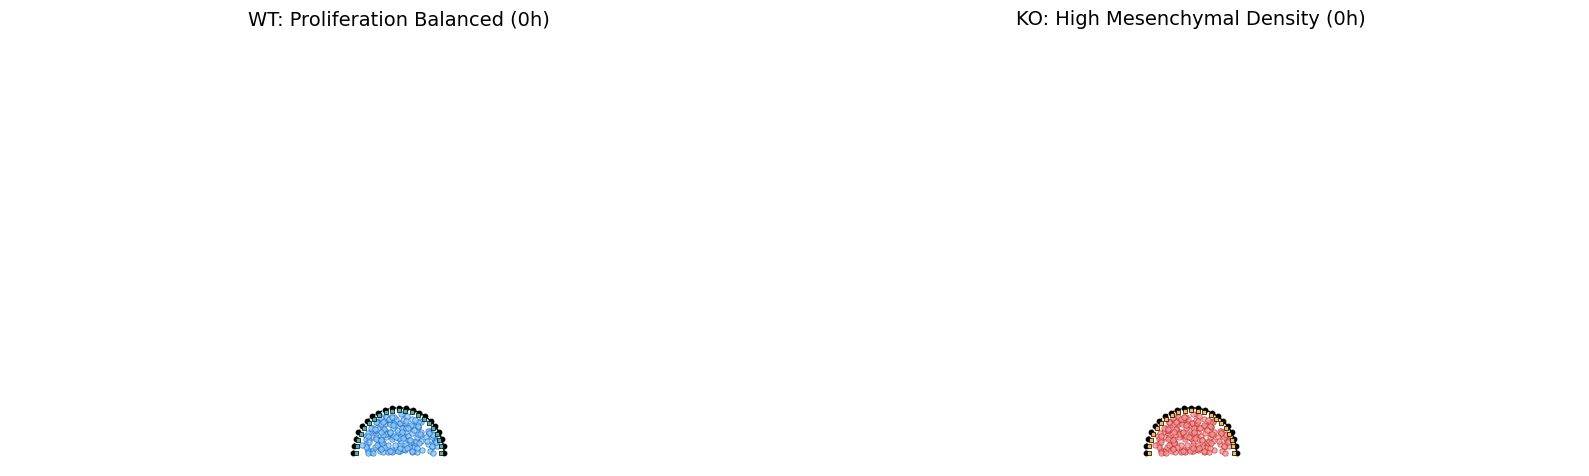

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 核心参数 (完全同步你的 Video 参数)
# ==========================================
INITIAL_RADIUS = 35.0   
PERI_CELL_LEN = 5.0     
MESENCHYME_SIZE = 4.0
TOTAL_TIME = 0  # [修改] 现在设为 0 也没问题了
DT = 1.0

# 边界参数
BASAL_SCALE = 0.94       
MESENCHYME_LIMIT = 0.90  

# 细胞动力学参数
MESENCHYME_PROLIF_RATE = 0.04
BASAL_TO_PERIDERM_RATE = 0.015  
PERIDERM_PROLIF_RATE_WT = 0.020
PERIDERM_PROLIF_RATE_KO = 0.0

# 视觉显示参数
VISUAL_SIZE_PERI = 10   
VISUAL_SIZE_BASAL = 12  
VISUAL_SIZE_MES = 15    

class Cell:
    def __init__(self, cell_type, x, y):
        self.type = cell_type
        self.x, self.y = x, y

# ==========================================
# 2. 模拟函数 (Snapshot 版 - 修复 0h 报错)
# ==========================================
def run_simulation_final_snapshot(is_ko=False, seed=None):
    if seed is not None:
        np.random.seed(seed)
        
    cells = []
    
    # 初始化
    initial_perimeter = np.pi * INITIAL_RADIUS
    num_init_cells = int(initial_perimeter / PERI_CELL_LEN)
    current_num_periderm = num_init_cells
    
    # [关键修复] 在循环前初始化 current_radius
    current_radius = INITIAL_RADIUS 
    prev_radius = INITIAL_RADIUS

    # 间充质初始化 (200个)
    for _ in range(200):
        max_r = INITIAL_RADIUS * MESENCHYME_LIMIT
        r = np.sqrt(np.random.uniform(0, 1)) * (max_r - 1)
        theta = np.random.uniform(0, np.pi)
        cells.append(Cell('Mesenchyme', r * np.cos(theta), r * np.sin(theta)))
    
    # 循环 (TOTAL_TIME)
    for t in range(int(TOTAL_TIME/DT)):
        
        # A. 周皮生长 (分化 + 自增殖)
        estimated_basal_count = current_num_periderm 
        new_from_basal = np.random.binomial(estimated_basal_count, BASAL_TO_PERIDERM_RATE)
        
        peri_prolif_rate = PERIDERM_PROLIF_RATE_KO if is_ko else PERIDERM_PROLIF_RATE_WT
        new_from_self = np.random.binomial(current_num_periderm, peri_prolif_rate)
        
        current_num_periderm += (new_from_basal + new_from_self)
        
        # B. 物理反馈
        max_perimeter = current_num_periderm * PERI_CELL_LEN
        current_radius = max_perimeter / np.pi
        
        expansion_ratio = current_radius / prev_radius if prev_radius > 0 else 1.0
        prev_radius = current_radius
        
        for c in cells:
            if c.type == 'Mesenchyme':
                c.x *= expansion_ratio
                c.y *= expansion_ratio

        # C. 间充质动力学 (指数增殖 + 边界限制)
        current_limit_radius = current_radius * MESENCHYME_LIMIT
        
        mes_cells = [c for c in cells if c.type == 'Mesenchyme']
        num_mes = len(mes_cells)
        num_new_mes = np.random.binomial(num_mes, MESENCHYME_PROLIF_RATE)
        
        new_mes_list = []
        if num_new_mes > 0:
            parents = np.random.choice(mes_cells, num_new_mes)
            for p in parents:
                new_mes_list.append(Cell('Mesenchyme', p.x + np.random.normal(0,1), p.y + np.random.normal(0,1)))
        
        cells.extend(new_mes_list)
        
        for c in cells:
            if c.type == 'Mesenchyme':
                c.x += np.random.normal(0, 0.4)
                c.y += np.random.uniform(-0.2, 0.4)
                dist = np.sqrt(c.x**2 + c.y**2)
                if dist > current_limit_radius:
                    c.x *= (current_limit_radius / dist)
                    c.y *= (current_limit_radius / dist)

    # --- 最终状态组装 ---
    final_snapshot = [c for c in cells] # 只有间充质
    
    # 添加最终周皮
    for i in range(current_num_periderm):
        angle = np.pi * i / (current_num_periderm - 1) if current_num_periderm > 1 else 0
        final_snapshot.append(Cell('Periderm', current_radius*np.cos(angle), current_radius*np.sin(angle)))
        
    # 添加最终基底 (视觉上与周皮 1:1)
    num_basal_visual = current_num_periderm
    r_basal = current_radius * BASAL_SCALE
    for i in range(num_basal_visual):
        angle = np.pi * i / (num_basal_visual - 1) if num_basal_visual > 1 else 0
        final_snapshot.append(Cell('Basal', r_basal*np.cos(angle), r_basal*np.sin(angle)))
        
    return final_snapshot

# ==========================================
# 绘图函数 (视觉优化版 - 匹配 Video)
# ==========================================
def plot_simulation_snapshot_final(ax, cells, title, color_theme='red'):
    mes_cells = [c for c in cells if c.type == 'Mesenchyme']
    peri_cells = [c for c in cells if c.type == 'Periderm']
    basal_cells = [c for c in cells if c.type == 'Basal'] 
    
    mx = [c.x for c in mes_cells]
    my = [c.y for c in mes_cells]
    
    if color_theme == 'red':
        m_color = '#ef9a9a' 
        m_edge = '#c62828'
        basal_color = '#ffb74d' 
    else:
        m_color = '#90caf9' 
        m_edge = '#1565c0'
        basal_color = '#4db6ac' 
        
    # 1. 间充质 (使用 VISUAL_SIZE_MES)
    ax.scatter(mx, my, c=m_color, s=VISUAL_SIZE_MES, alpha=0.8, edgecolors=m_edge, linewidth=0.5, label='Mesenchyme', zorder=1)
    
    # 2. 周皮
    peri_sorted = sorted(peri_cells, key=lambda c: np.arctan2(c.y, c.x))
    px = [c.x for c in peri_sorted]
    py = [c.y for c in peri_sorted]
    
    # 虚线画细一点
    ax.plot(px, py, c='black', linewidth=1.0, linestyle='--', zorder=2) 
    # 使用 VISUAL_SIZE_PERI
    ax.scatter(px, py, c='black', s=VISUAL_SIZE_PERI, marker='o', zorder=3, label='Periderm')
    
    # 3. 基底 (使用 VISUAL_SIZE_BASAL)
    bx = [c.x for c in basal_cells]
    by = [c.y for c in basal_cells]
    ax.scatter(bx, by, c=basal_color, s=VISUAL_SIZE_BASAL, marker='s', edgecolors='black', linewidth=0.5, zorder=4, label='Basal')

    ax.set_title(title, fontsize=14, pad=10)
    ax.set_aspect('equal')
    
    # [关键] 统一宽视野 (-300, 300)
    ax.set_xlim(-300, 300)
    ax.set_ylim(-10, 320)
    ax.axis('off')

# ==========================================
# 运行并保存
# ==========================================
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

PLOT_SEED = 2026
print("Generating Final Synchronized Snapshots (0h)...")

wt_snapshot = run_simulation_final_snapshot(is_ko=False, seed=PLOT_SEED)
ko_snapshot = run_simulation_final_snapshot(is_ko=True, seed=PLOT_SEED)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8)) # 画布调大

plot_simulation_snapshot_final(ax1, wt_snapshot, "WT: Proliferation Balanced (0h)", color_theme='blue')
plot_simulation_snapshot_final(ax2, ko_snapshot, "KO: High Mesenchymal Density (0h)", color_theme='red')

plt.tight_layout()
plt.savefig('Simulation_Snapshots_0h.pdf', format='pdf', dpi=300, bbox_inches='tight')
print("最终快照 (0h) 已保存为: Simulation_Snapshots_0h.pdf")

plt.show()